# Overview

As I have seen in `20260616__umd_variations.ipynb`, there seems to be some 
trends based purely on coin price, but it seems to have an upper limit of 
~`1`-`1.3` (at least so far).  Another avenue that I have not explored yet
that could lead to more consistently higher Sharpe Ratios is to look at
how volume of a coin influences price.


In [1]:
from binance.client import Client as bnb_client
from datetime import datetime, timezone
import pandas as pd 
import os
from dataclasses import dataclass
from wall_street_quants_course_project.models import (
    LevelFrame,
    PctChangeFrame,
    PriceFrame,
    ReturnFrame,
    WeightFrame,
    PriceNeutralWeightFrame,
    FullyInvestedWeightFrame,
)
import numpy as np
import matplotlib.pyplot as plt
import math

client = bnb_client(tld='US')

In [2]:
# get_exchange_info() returns every listed symbol with its trading status,
# base asset, and quote asset — best for filtering to active USDT pairs.
exchange_info = client.get_exchange_info()

usdt_symbols = [
    s['symbol']
    for s in exchange_info['symbols']
    if s['quoteAsset'] == 'USDT' and s['status'] == 'TRADING'
]

print(f"Active USDT pairs: {len(usdt_symbols)}")
usdt_symbols[:5]

Active USDT pairs: 201


['BTCUSDT', 'ETHUSDT', 'XRPUSDT', 'BCHUSDT', 'LTCUSDT']

In [3]:
univ = usdt_symbols[:]
# Binance Kline API Docs: 
#   https://developers.binance.com/docs/binance-spot-api-docs/rest-api/market-data-endpoints#klinecandlestick-data
freq = '1M'
pd_freq = 'MS'

start_ts = '2021-01-01'
end_ts = '2025-12-31'
tcost_bps = 20

In [4]:
def get_binance_px(symbol,freq,start_ts=start_ts,end_ts=end_ts):
    data = client.get_historical_klines(symbol,freq,start_ts,end_ts)
    columns = ['open_time','open','high','low','close','volume','close_time','quote_volume',
    'num_trades','taker_base_volume','taker_quote_volume','ignore']

    data = pd.DataFrame(data,columns = columns)
    
    # Convert from POSIX timestamp (number of millisecond since jan 1, 1970)
    data['open_time'] = data['open_time'].map(lambda x: datetime.fromtimestamp(x/1000, timezone.utc))
    data['close_time'] = data['close_time'].map(lambda x: datetime.fromtimestamp(x/1000, timezone.utc))
    return data 

In [5]:
px = {}
quote_vol = {}
vol = {}
for x in univ:
    data = get_binance_px(x,freq,start_ts,end_ts)
    px[x] = data.set_index('open_time')['close']
    quote_vol[x] = data.set_index('open_time')['quote_volume']
    vol[x] = data.set_index('open_time')['volume']

### Setup/Validate DataFrames for Analysis

Get the data into DataFrames as in other analyzes a
and make easy to read + validate.  Then run DMU on the new
data to ensure it's more or less the same as in the 
`20260616__umd_variations.ipynb` notebook.

In [6]:
def get_LevelFrame(data_dict: dict[pd.Series], index_freq: str = pd_freq, remove_tz: bool = True) -> LevelFrame:
    new: pd.DataFrame = pd.DataFrame(data_dict).astype(float)
    new = new.reindex(pd.date_range(new.index[0],new.index[-1],freq=pd_freq))
    if remove_tz:
        new.index = new.index.tz_localize(None) # Drop UTC timestamp, keep only date
    new: LevelFrame = LevelFrame.validate(new)
    return new

In [7]:
px: pd.DataFrame = PriceFrame.validate(get_LevelFrame(px))
quote_vol: LevelFrame = get_LevelFrame(quote_vol)
vol: LevelFrame = get_LevelFrame(vol)

In [8]:
def calc_dmu(px: pd.DataFrame, tcost_bps=20):
    # Calc returns from price
    ret = ReturnFrame.validate(px.copy(deep=True).pct_change(fill_method=None))

    # Calc weights
    w = ret.shift(periods=1).rolling(11).mean()
    w = w.rank(axis=1)
    w = w.subtract(w.mean(axis=1), axis=0)
    w = w.divide(w.abs().sum(axis=1), axis=0)
    w = -1*w
    w = PriceNeutralWeightFrame.validate(w)

    # Calc port contrib return
    port_contrib_ret = (w.shift() * ret)

    gross_ret = port_contrib_ret.sum(axis=1)
    to = (
        w.fillna(0) - w.shift().fillna(0)
    ).abs().sum(axis=1)
    net_ret = gross_ret - to * tcost_bps * 1e-4
    return (
        ret,
        w,
        port_contrib_ret,
        gross_ret,
        net_ret,
    )

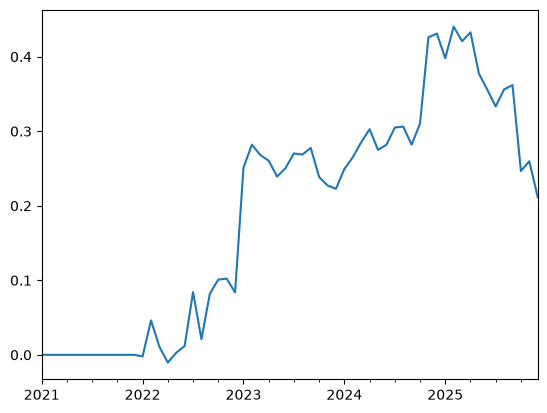

In [9]:
(
    ret,
    w,
    port_contrib_ret,
    gross_ret,
    net_ret,
) = calc_dmu(px)
net_ret.cumsum().plot()
plt.show()

##### DMU Analysis Note

It seems that "Down Minus Up" is returning slightly worse than in the
other notebook.  That could be for a few reasons: 

1. The universe is slightly different than other day
2. The way I broke out months before is different than in this notebook

I feel that overall, the graph has the same shape, so I am happy enough
with it.  One concern I had with the other notebook is that maybe I 
simply happened to divide the data into monthly data in a way that happened
to show a pattern and it wouldn't be robust.  In some ways, I am happy
to see that the DMU is still holding somewhat though the data is slightly
different.  That gives me a bit more confidence there could be an actual
somewhat robust pattern with it.

### See if connection between coin price + volume

In `20260616__umd_variations.ipynb`, the coins that started 2022
with the lower half of coin values seemed to have a strategy with
a fairly high Sharpe Ratio of ~1.3+.  I would like to see if there
is a signal within the volume of these coins that I could look at
as well to capture this signal for other strategies.

In [10]:
def get_halves_of_2022_start_price(px: pd.DataFrame):
    # NOTE: this is just example -- in future use like volume or something
    tmp = px[px.index == datetime(2022, 1, 1)].dropna(axis=1).rank(axis=1).T
    tmp = tmp.sort_values(by=tmp.columns[0], ascending=False)
    top_half_coins_by_2022_start_price = tmp.index.to_numpy()[:len(tmp.index)//2]
    bottom_half_coins_by_2022_start_price = tmp.index.to_numpy()[len(tmp.index)//2:]
    return top_half_coins_by_2022_start_price, bottom_half_coins_by_2022_start_price

In [11]:
(
    top_half_coins_by_2022_start_price, bottom_half_coins_by_2022_start_price
) = get_halves_of_2022_start_price(px)

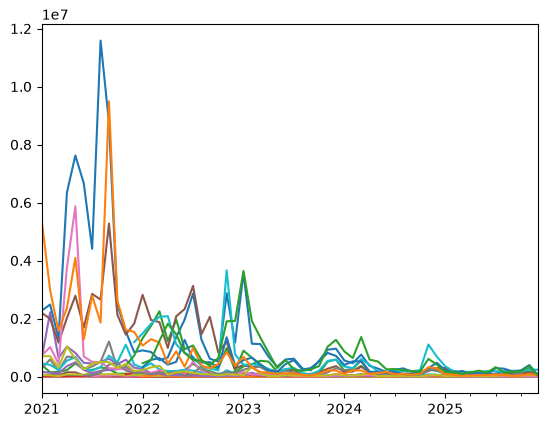

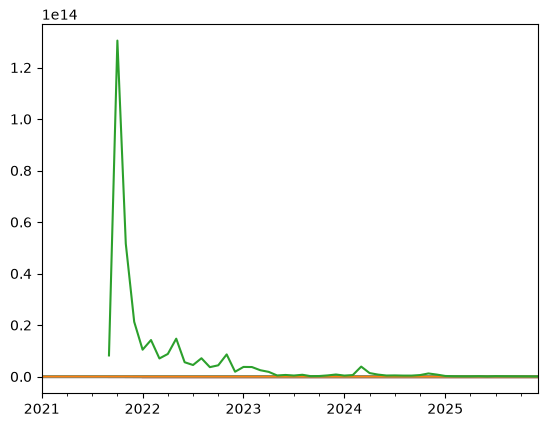

In [12]:
vol[top_half_coins_by_2022_start_price].plot(legend=False)
vol[bottom_half_coins_by_2022_start_price].plot(legend=False)
plt.show()

In [13]:
print(vol[top_half_coins_by_2022_start_price].mean(axis=1).describe())
print(vol[bottom_half_coins_by_2022_start_price].mean(axis=1).describe())

count    6.000000e+01
mean     3.353115e+05
std      3.978500e+05
min      3.182986e+04
25%      5.806694e+04
50%      1.597732e+05
75%      4.552292e+05
max      1.744738e+06
dtype: float64
count    6.000000e+01
mean     3.141873e+11
std      1.190502e+12
min      6.580727e+08
25%      5.430182e+09
50%      2.268661e+10
75%      1.645186e+11
max      8.699203e+12
dtype: float64


#### Analysis on coins + volume based on coin price at start of 2022

It is tough to see an obvious pattern with the volume of the top and bottom
half of coins by their prices at the start of 2022.  I am thinking it might
be more worth while trying out some different strategies using volume as a
factor and see if it's possible to find some ones with higher Sharpe Ratios.


### DMU Strategy with Lower-Volume-Half Filter

Same structure as `calc_dmu_outliers_only_lower_half_price` from
`20260616__umd_variations.ipynb`, but instead of restricting to coins in
the lower half by 12-month rolling average price, we restrict to coins in
the lower half by 12-month rolling average volume.

> **Note:** `vol` here is base-unit volume (coin quantity traded), not USDT
> quote volume. Lower base-unit volume can simply reflect a higher per-unit
> price, so this filter may overlap substantially with the lower-half-price
> filter. Consider switching to `quote_volume` for a cleaner signal.

In [14]:
def calc_dmu_outliers_only_lower_half_vol(
    px: PriceFrame,
    vol: LevelFrame,
    tcost_bps: int = 20,
    outlier_pct: float = 0.2,
) -> tuple:
    ret = px.copy(deep=True).pct_change(fill_method=None)

    # Restrict universe to coins in the lower half by 12-month rolling avg volume
    vol_ma = vol.rolling(12).mean()
    vol_pct_rank = vol_ma.rank(axis=1, pct=True)
    is_lower_half_vol = vol_pct_rank < 0.5

    # DMU momentum signal: 11-month MA of 1-month lagged returns
    signal = ret.shift(periods=1).rolling(11).mean()
    signal = signal.where(is_lower_half_vol)

    # Keep only outlier coins at each period
    pct_rank = signal.rank(axis=1, pct=True)
    is_outlier = (
        (pct_rank <= outlier_pct)
        | (pct_rank >= 1 - outlier_pct)
    )
    signal = signal.where(is_outlier)

    w = signal.rank(axis=1)
    w = w.subtract(w.mean(axis=1), axis=0)
    w = w.divide(w.abs().sum(axis=1), axis=0)
    w = -1 * w

    port_contrib_ret = w.shift() * ret
    gross_ret = port_contrib_ret.sum(axis=1)
    to = (w.fillna(0) - w.shift().fillna(0)).abs().sum(axis=1)
    net_ret = gross_ret - to * tcost_bps * 1e-4

    return (ret, w, port_contrib_ret, gross_ret, net_ret)

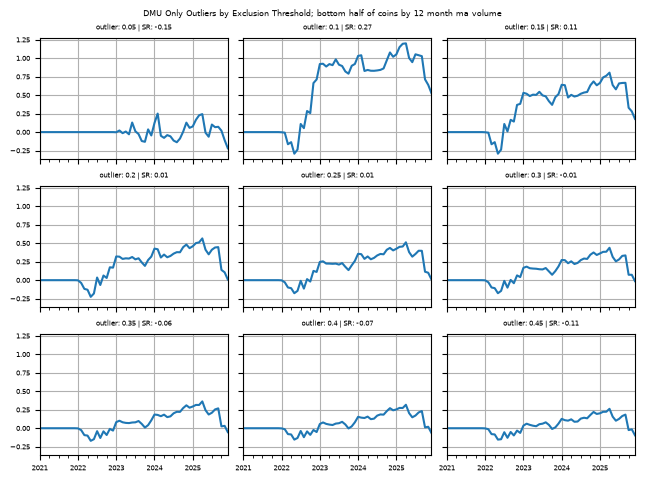

In [15]:
outlier_pcts = [
    outlier_thresh / 100
    for outlier_thresh in range(5, 50, 5)
]

n_cols = 3
n_rows = math.ceil(len(outlier_pcts) / n_cols)

with plt.rc_context({"font.size": 5}):
    fig, ax = plt.subplots(n_rows, n_cols, sharex=True, sharey=True)
    fig.set_tight_layout(tight=True)
    fig.suptitle(
        "DMU Only Outliers by Exclusion Threshold; "
        "bottom half of coins by 12 month ma volume"
    )
    axes = ax.flatten()

    for i, outlier_pct in enumerate(outlier_pcts):
        (
            ret, w, port_contrib_ret, gross_ret, net_ret,
        ) = calc_dmu_outliers_only_lower_half_vol(
            px, vol, outlier_pct=outlier_pct
        )
        sharpe = (net_ret.mean() / net_ret.std()) * np.sqrt(12)
        axes[i].set_title(
            f'outlier: {outlier_pct} | SR: {sharpe:.2f}',
            fontsize=5,
        )
        net_ret.cumsum().plot(ax=axes[i])
        axes[i].grid()
    plt.show()

### Analysis: Why the Bottom-Half-by-Price DMU Strategy Has the Highest SR

From `20260616__umd_variations.ipynb`, filtering to coins in the **lower half
by price** before applying the DMU outlier strategy consistently achieves the
best Sharpe Ratios (~1.13–1.24 at outlier thresholds of 30–45%).

A few reasons this likely works:

- **Market efficiency**: Lower-priced coins tend to be smaller-cap altcoins
  with less institutional coverage. Momentum and mean-reversion signals are
  stronger in less efficient markets.
- **DMU is a reversal bet**: The strategy is short-momentum (bets losers
  outperform winners). This contrarian signal is more reliable in coins that
  are prone to overreaction — typically the smaller, noisier names.
- **Outlier filtering compounds this**: Keeping only the most extreme signal
  coins within an already-noisy group amplifies the reversal edge.


### DMU Strategy Further Variations Including Volume

Below I will parameterize the DMU function and then try out varying
combinations including volume to see if I can find things higher than
the Sharpe Ratio limit before of ~1.2-1.3.

In [16]:
def calc_dmu_parameterized(
    px: PriceFrame,
    vol: LevelFrame,
    px_lower_pct: float = 0.1,
    px_upper_pct: float = 0.9,
    px_ma_months: int = 12,
    px_delay_months: int = 1,
    keep_outside_px: bool = True,
    vol_lower_pct: float = 0.1,
    vol_upper_pct: float = 0.9,
    vol_ma_months: int = 12,
    keep_outside_vol: bool = True,
    use_vol_filter: bool = True,
    tcost_bps: int = 20,
    reversal: bool = True
) -> tuple:
    ret = px.copy(deep=True).pct_change(fill_method=None)

    # Momentum signal: delayed MA of returns
    signal = ret.shift(px_delay_months).rolling(px_ma_months-px_delay_months).mean()

    # Volume universe filter (skipped when use_vol_filter=False)
    if use_vol_filter:
        vol_pct_rank = (
            vol.rolling(vol_ma_months).mean().rank(axis=1, pct=True)
        )
        if keep_outside_vol:
            in_vol_universe = (
                (vol_pct_rank <= vol_lower_pct)
                | (vol_pct_rank >= vol_upper_pct)
            )
        else:
            in_vol_universe = (
                (vol_pct_rank >= vol_lower_pct)
                & (vol_pct_rank <= vol_upper_pct)
            )
        signal = signal.where(in_vol_universe)

    # Price signal filter: keep outliers or middle of signal distribution
    signal_rank = signal.rank(axis=1, pct=True)
    if keep_outside_px:
        in_px_universe = (
            (signal_rank <= px_lower_pct)
            | (signal_rank >= px_upper_pct)
        )
    else:
        in_px_universe = (
            (signal_rank >= px_lower_pct)
            & (signal_rank <= px_upper_pct)
        )
    signal = signal.where(in_px_universe)

    w = signal.rank(axis=1)
    w = w.subtract(w.mean(axis=1), axis=0)
    w = w.divide(w.abs().sum(axis=1), axis=0)
    if reversal:
        w = -1 * w

    port_contrib_ret = w.shift() * ret
    gross_ret = port_contrib_ret.sum(axis=1)
    to = (w.fillna(0) - w.shift().fillna(0)).abs().sum(axis=1)
    net_ret = gross_ret - to * tcost_bps * 1e-4

    return (ret, w, port_contrib_ret, gross_ret, net_ret)

In [17]:
def plot_dmu_variation(
    px: PriceFrame,
    vol: LevelFrame,
    px_lower_pct: float = 0.1,
    px_upper_pct: float = 0.9,
    px_ma_months: int = 12,
    px_delay_months: int = 1,
    keep_outside_px: bool = True,
    vol_lower_pct: float = 0.1,
    vol_upper_pct: float = 0.9,
    vol_ma_months: int = 12,
    keep_outside_vol: bool = True,
    use_vol_filter: bool = True,
    tcost_bps: int = 20,
    reversal: bool = True
):

    with plt.rc_context({"font.size": 5}):
        fig, ax = plt.subplots(1, 1, sharex=True, sharey=True)

        (_, _, _, _, net_ret) = calc_dmu_parameterized(
            px, vol,
            px_lower_pct = px_lower_pct,
            px_upper_pct = px_upper_pct,
            px_ma_months = px_ma_months,
            px_delay_months = px_delay_months,
            keep_outside_px = keep_outside_px,
            vol_lower_pct = vol_lower_pct,
            vol_upper_pct = vol_upper_pct,
            vol_ma_months = vol_ma_months,
            keep_outside_vol = keep_outside_vol,
            use_vol_filter = use_vol_filter,
            tcost_bps = tcost_bps,
            reversal=reversal,
        )
        sharpe = (net_ret.mean() / net_ret.std()) * np.sqrt(12)
        ax.set_title(
            f'SR: {sharpe:.2f}', fontsize=5
        )
        net_ret.cumsum().plot(ax=ax)

### Volume

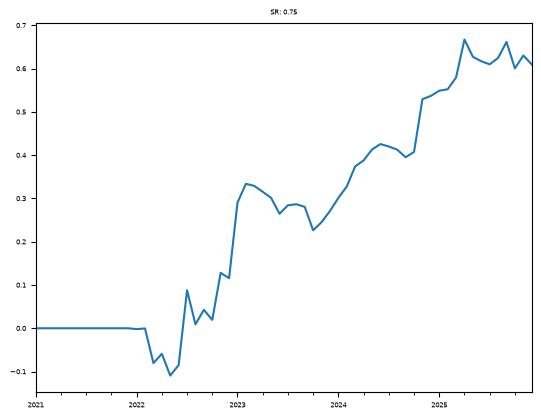

In [79]:
px_thresh = (0.0, 1.0); keep_outside_px=False; px_ma_months=12; px_delay_months=0
vol_thresh = (0.2, 0.5); keep_outside_vol=False; vol_ma_months=12
reversal=True
plot_dmu_variation(
    px, vol,
    px_lower_pct=px_thresh[0], px_upper_pct=px_thresh[1], px_ma_months=px_ma_months, px_delay_months=px_delay_months, keep_outside_px=keep_outside_px,
    vol_lower_pct=vol_thresh[0], vol_upper_pct=vol_thresh[1], vol_ma_months=vol_ma_months, keep_outside_vol=keep_outside_vol,
    tcost_bps=20,reversal=reversal
)

### Quote Volume

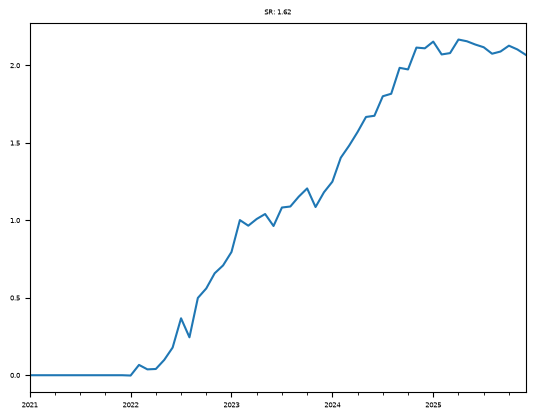

In [25]:
px_thresh = (0.20, 0.9); keep_outside_px=True; px_ma_months=12; px_delay_months=0
vol_thresh = (0.1, 0.45); keep_outside_vol=False; vol_ma_months=12

plot_dmu_variation(
    px, quote_vol,
    px_lower_pct=px_thresh[0], px_upper_pct=px_thresh[1], px_ma_months=px_ma_months, px_delay_months=px_delay_months, keep_outside_px=keep_outside_px,
    vol_lower_pct=vol_thresh[0], vol_upper_pct=vol_thresh[1], vol_ma_months=vol_ma_months, keep_outside_vol=keep_outside_vol,
    tcost_bps=20,
)

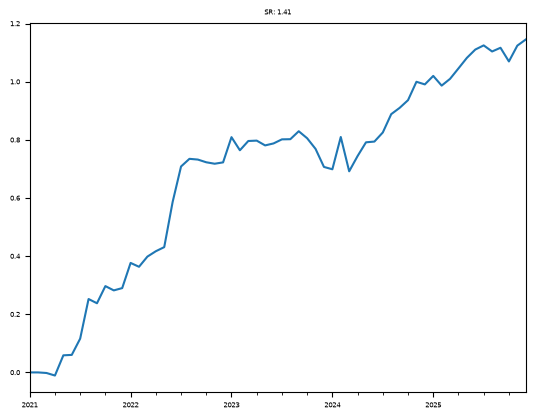

In [26]:
px_thresh = (0.2, 0.8); keep_outside_px=False; px_ma_months=1; px_delay_months=0
vol_thresh = (0.5, 0.9); keep_outside_vol=True; vol_ma_months=3
reversal=True
plot_dmu_variation(
    px, quote_vol,
    px_lower_pct=px_thresh[0], px_upper_pct=px_thresh[1], px_ma_months=px_ma_months, px_delay_months=px_delay_months, keep_outside_px=keep_outside_px,
    vol_lower_pct=vol_thresh[0], vol_upper_pct=vol_thresh[1], vol_ma_months=vol_ma_months, keep_outside_vol=keep_outside_vol,
    tcost_bps=20,reversal=reversal,
)

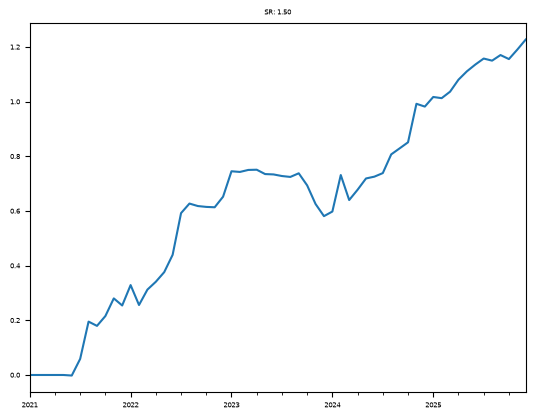

In [27]:
px_thresh = (0.2, 0.8); keep_outside_px=False; px_ma_months=1; px_delay_months=0
vol_thresh = (0.5, 0.9); keep_outside_vol=True; vol_ma_months=6
reversal=True
plot_dmu_variation(
    px, quote_vol,
    px_lower_pct=px_thresh[0], px_upper_pct=px_thresh[1], px_ma_months=px_ma_months, px_delay_months=px_delay_months, keep_outside_px=keep_outside_px,
    vol_lower_pct=vol_thresh[0], vol_upper_pct=vol_thresh[1], vol_ma_months=vol_ma_months, keep_outside_vol=keep_outside_vol,
    tcost_bps=20,reversal=reversal,
)

### Adding Volume Analysis

While it seems to be possible to get Sharpe Ratios a little higher than 
before using volume, it's only like .1-.2 higher, and it feels somewhat
random what is able to produce higher returns or not.

I am thinking in the future, it might be worthwhile continuing to down 
path of using volume, but further explore like magnitude of changes in 
price or volume and how that might affect returns.  I feel like ranking
the assets can be nice, but I am wondering if I am really able to tune
into a signal from this approach as I feel it depends on selecting the
"right candidates" to be ranked and weighted against each other, which
I am a little blind to.

I feel like maybe if I am able to like find signals that change in
magnitude, it may give me an easier time selecting optimal assets for
a given strategy at each index over time as I can look at the signal
per asset easier and it is interpetable on its own rather than needing
a pool of them to be ranked in order to see how strategy will do.

In [41]:
px_thresh = (0.20, 0.9); keep_outside_px=True; px_ma_months=12; px_delay_months=0
vol_thresh = (0.1, 0.45); keep_outside_vol=False; vol_ma_months=12
reversal=True
strat1 = calc_dmu_parameterized(
    px, quote_vol,
    px_lower_pct=px_thresh[0], px_upper_pct=px_thresh[1], px_ma_months=px_ma_months, px_delay_months=px_delay_months, keep_outside_px=keep_outside_px,
    vol_lower_pct=vol_thresh[0], vol_upper_pct=vol_thresh[1], vol_ma_months=vol_ma_months, keep_outside_vol=keep_outside_vol,
    tcost_bps=20,reversal=reversal,
)

In [42]:
px_thresh = (0.2, 0.8); keep_outside_px=False; px_ma_months=1; px_delay_months=0
vol_thresh = (0.5, 0.9); keep_outside_vol=True; vol_ma_months=6
reversal=True
strat2 = calc_dmu_parameterized(
    px, quote_vol,
    px_lower_pct=px_thresh[0], px_upper_pct=px_thresh[1], px_ma_months=px_ma_months, px_delay_months=px_delay_months, keep_outside_px=keep_outside_px,
    vol_lower_pct=vol_thresh[0], vol_upper_pct=vol_thresh[1], vol_ma_months=vol_ma_months, keep_outside_vol=keep_outside_vol,
    tcost_bps=20,reversal=reversal,
)

In [43]:
w1 = strat1[1]
w2 = strat2[1]

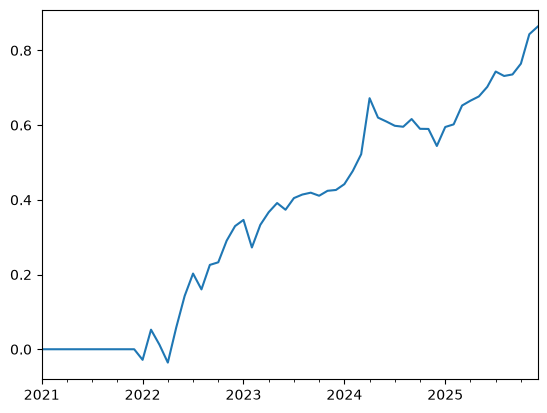

Combined Sharpe: 1.28


In [44]:
combined_ret = (-1 * (w1 * .5 + w2 * .5) * ret.shift()).sum(axis=1)
combined_ret.cumsum().plot()

plt.show()
sharpe = (combined_ret.mean() / combined_ret.std()) * np.sqrt(12)
print(f'Combined Sharpe: {sharpe:.2f}')

Combining two together doesn't seem to combine the way I thought it would.
Seems I need to flip sign of weights otherwise it isn't combining.  I think
I may get more value out of taking a different tact, such as looking at
strategies that take into account magnitude and/or trying to optimize
strategies for smaller time ranges such as 1-2 years, not a 5 year period.